In [ ]:
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt

In [2]:
opinion_data = pd.read_csv("../data/zib/Opinion_data/survey_data_original_JPN.csv", index_col="Date", parse_dates=["Date"])
infection_data = pd.read_csv("../data/japan-covid-data.csv", index_col="date", parse_dates=["date"])

In [3]:
start_date, end_date = datetime(2020, 3, 12), datetime(2020, 6, 26)
new_opinion_data = opinion_data.loc[start_date:end_date]
new_infection_data = infection_data.loc[start_date:end_date]

In [10]:
new_opinion_data = new_opinion_data.rename(columns={"1": -3, "2": -2, "3": -1, "4": 0, "5": 1, "6": 2, "7": 3})
new_opinion_data["Expected_infection"] = new_opinion_data.apply(lambda row: sum(row[i] * i for i in range(-3, 4)), axis=1)

In [12]:
new_opinion_data = new_opinion_data/100

In [13]:
new_opinion_data

,-3,-2,-1,0,1,2,3,Expected_infection
Date,,,,,,,,
2020-03-12,0.053,0.083,0.127,0.215,0.241,0.126,0.154,0.503
2020-03-27,0.048,0.054,0.093,0.201,0.251,0.170,0.183,0.795
2020-04-13,0.024,0.030,0.075,0.145,0.231,0.196,0.299,1.313
2020-04-24,0.028,0.036,0.068,0.155,0.237,0.195,0.282,1.249
2020-05-15,0.072,0.076,0.147,0.236,0.249,0.104,0.115,0.287
2020-05-29,0.079,0.095,0.150,0.245,0.236,0.097,0.098,0.147
2020-06-12,0.106,0.111,0.174,0.250,0.209,0.076,0.075,-0.128
2020-06-26,0.124,0.110,0.167,0.217,0.219,0.080,0.083,-0.131


In [19]:
def normalize(dataframe: pd.DataFrame, column: str) -> pd.Series:
    return (dataframe[column] - dataframe[column].min()) / (dataframe[column].max() - dataframe[column].min())

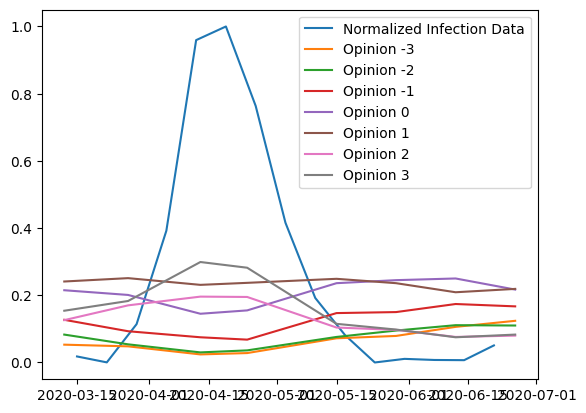

In [28]:
inf_idx = new_infection_data['new_cases'] > 0
inf_norm = normalize(new_infection_data[inf_idx], 'new_cases')
# opn1_norm = normalize(new_opinion_data, -3)
# opn2_norm = normalize(new_opinion_data, -2)
# opn3_norm = normalize(new_opinion_data, -1)
# opn4_norm = normalize(new_opinion_data, 0)
# opn5_norm = normalize(new_opinion_data, 1)
# opn6_norm = normalize(new_opinion_data, 2)
# opn7_norm = normalize(new_opinion_data, 3)
plt.plot(new_infection_data[inf_idx].index, inf_norm, label='Normalized Infection Data')
plt.plot(new_opinion_data.index, new_opinion_data[-3], label='Opinion -3')
plt.plot(new_opinion_data.index, new_opinion_data[-2], label='Opinion -2')
plt.plot(new_opinion_data.index, new_opinion_data[-1], label='Opinion -1')
plt.plot(new_opinion_data.index, new_opinion_data[0], label='Opinion 0')
plt.plot(new_opinion_data.index, new_opinion_data[1], label='Opinion 1')
plt.plot(new_opinion_data.index, new_opinion_data[2], label='Opinion 2')
plt.plot(new_opinion_data.index, new_opinion_data[3], label='Opinion 3')
plt.legend()
plt.show()

In [9]:
opinion_data_2 = new_opinion_data.reindex(new_infection_data.index)

In [15]:
opinion_data_2.loc[new_opinion_data.index]

,1,2,3,4,5,6,7
Date,,,,,,,
2020-03-12,5.3,8.3,12.7,21.5,24.1,12.6,15.4
2020-03-27,4.8,5.4,9.3,20.1,25.1,17.0,18.3
2020-04-13,2.4,3.0,7.5,14.5,23.1,19.6,29.9
2020-04-24,2.8,3.6,6.8,15.5,23.7,19.5,28.2
2020-05-15,7.2,7.6,14.7,23.6,24.9,10.4,11.5
2020-05-29,7.9,9.5,15.0,24.5,23.6,9.7,9.8
2020-06-12,10.6,11.1,17.4,25.0,20.9,7.6,7.5
2020-06-26,12.4,11.0,16.7,21.7,21.9,8.0,8.3
